# Árvores de regressão - exercícios 01

*Atenção! Devido descontinuação da base de imóveis boston os alunos devem utilizar a base de dados que se encontra em anexo.*

A base que utilizaremos contem os dados dos imóveis da california.
Considerem como variável Target (a ser prevista) a coluna median_house_value.
O dataset é muito semelhante ao de boston, contendo localização, quartos, banheiros e outras variáveis interessantes para construção do modelo.

In [36]:
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.tree import DecisionTreeRegressor
from sklearn import tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error


### 1. Certifique-se de que esta base está no formato adequado para o scikitlearn.
ok, essa tarefa é tão fácil que você vai até desconfiar. Mas é preciso ter confiança sobre os dados que se usa ;)

In [7]:
# carregar dados
df = pd.read_csv("housing.csv")

# visualizar
df.head()

# verificar tipos
df.info()

# verificar valores nulos
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [19]:
#Tratando valores nulos (se houver)
df.fillna(df.median(numeric_only=True), inplace=True)

In [17]:
#transformar variavel categorica:
df = pd.get_dummies(df, columns=['ocean_proximity'], drop_first=True)

### 2.  Visualize a matriz de correlação, e veja se aparentemente você encontra alguma variável com potencial preditivo interessante.

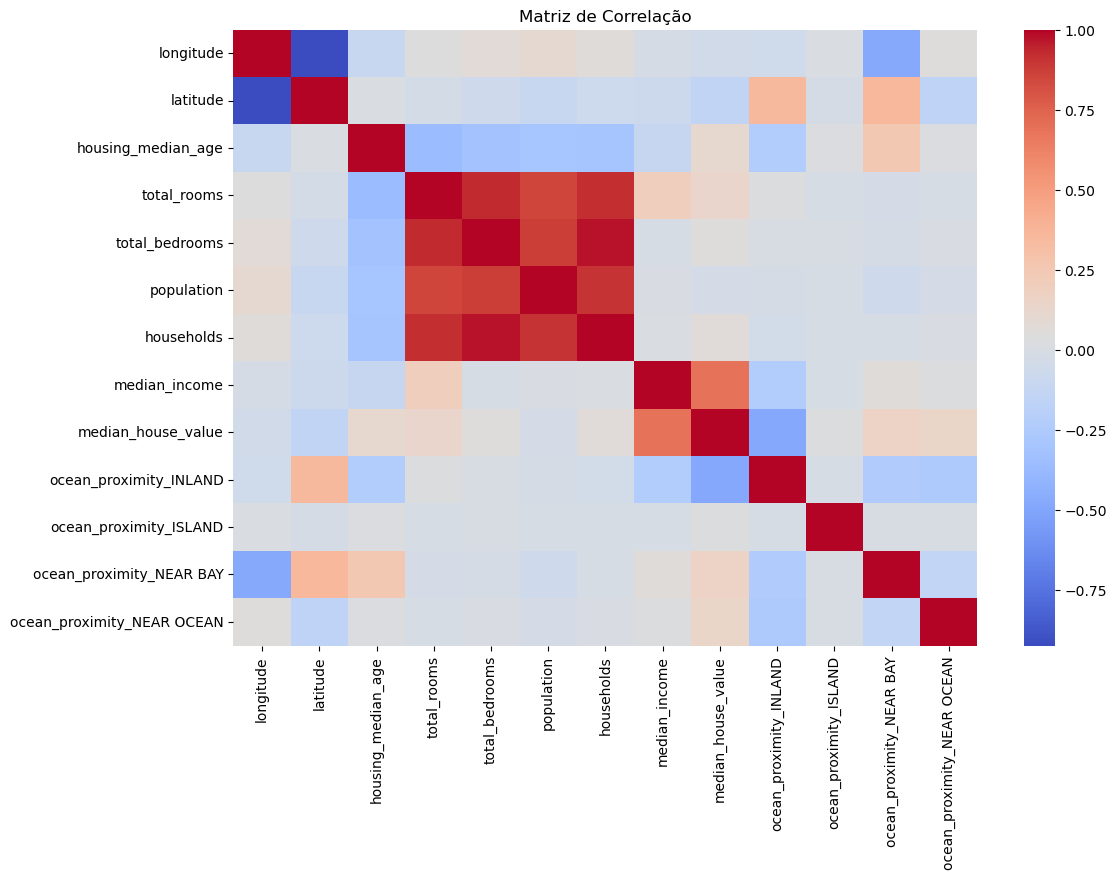

In [26]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=False, cmap='coolwarm')
plt.title("Matriz de Correlação")
plt.show()

In [28]:
#Para ver correlação com target:
df.corr()['median_house_value'].sort_values(ascending=False)

median_house_value            1.000000
median_income                 0.688075
ocean_proximity_NEAR BAY      0.160284
ocean_proximity_NEAR OCEAN    0.141862
total_rooms                   0.134153
housing_median_age            0.105623
households                    0.065843
total_bedrooms                0.049457
ocean_proximity_ISLAND        0.023416
population                   -0.024650
longitude                    -0.045967
latitude                     -0.144160
ocean_proximity_INLAND       -0.484859
Name: median_house_value, dtype: float64

### 3. Separe os dados em validação e teste

In [30]:
from sklearn.model_selection import train_test_split

X = df.drop('median_house_value', axis=1)
y = df['median_house_value']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

### 4. Treine duas árvores, uma com profundidade máxima = 8, outra com profundidade máxima = 2.

In [32]:
# Árvore 1 (profundidade 8)
tree_8 = DecisionTreeRegressor(max_depth=8, random_state=42)
tree_8.fit(X_train, y_train)

# Árvore 2 (profundidade 2)
tree_2 = DecisionTreeRegressor(max_depth=2, random_state=42)
tree_2.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=2, random_state=42)

### 5. Calcule o MSE de cada uma das árvores do item anterior para a base de treinamento e para a base de testes.

In [38]:
# previsões
y_train_pred_8 = tree_8.predict(X_train)
y_test_pred_8 = tree_8.predict(X_test)

y_train_pred_2 = tree_2.predict(X_train)
y_test_pred_2 = tree_2.predict(X_test)

# MSE
print("Árvore profundidade 8")
print("Treino:", mean_squared_error(y_train, y_train_pred_8))
print("Teste:", mean_squared_error(y_test, y_test_pred_8))

print("\nÁrvore profundidade 2")
print("Treino:", mean_squared_error(y_train, y_train_pred_2))
print("Teste:", mean_squared_error(y_test, y_test_pred_2))

Árvore profundidade 8
Treino: 3216767950.0365443
Teste: 3953859277.6822824

Árvore profundidade 2
Treino: 6697232159.457342
Teste: 6892967959.052412


### 6. Com base nos resultados do item anterior, qual árvore te parece mais adequada?

A árvore com profundidade 8 é mais adequada, pois apresentou um erro (MSE) significativamente menor tanto na base de treino quanto na base de teste.

Apesar de ser mais complexa, a diferença entre os erros de treino e teste não é tão grande, indicando que o modelo não está sofrendo overfitting severo.

Já a árvore com profundidade 2 apresentou erros muito elevados em ambas as bases, indicando underfitting, ou seja, o modelo é simples demais para capturar os padrões dos dados.

### 7. Faça uma visualização gráfica dessa árvore. Vamos discutir importância de variável mais adiante, mas veja a sua árvore, e pense um pouco: qual variável te parece mais "importante" na árvore?

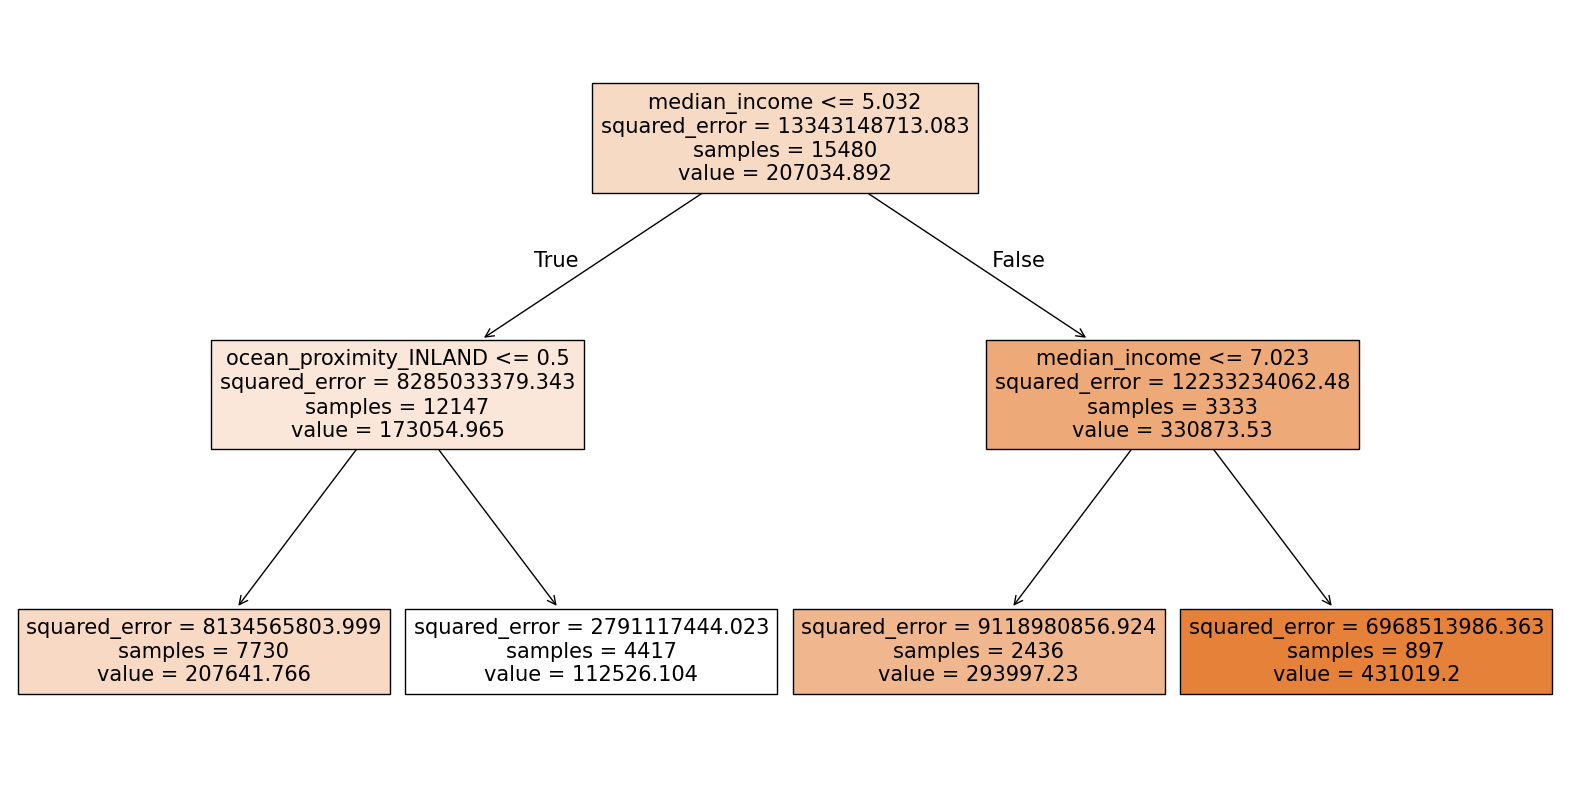

In [40]:
plt.figure(figsize=(20,10))
tree.plot_tree(
    tree_2,  # você pode trocar por tree_8
    feature_names=X.columns,
    filled=True
)
plt.show()

A variável que aparece no topo (primeiro split). Essa geralmente é a mais importante!